# Test on Small Graphs (5-30 nodes)

Poređenje svih algoritama uključujući brute force na malim primerima.
Brute force na small06-small10 (26-30 čvorova) može potrajati nekoliko minuta.

In [30]:
%run 02_test_on_small_graphs.ipynb

## Poređenje težina

In [20]:
small_files = sorted(Path('data/small').glob('*.stp'))

algorithms = [
    ('Brute Force', brute_force_steiner, True),
    ('MST Heuristic', mst_heuristic, False),
    ('Mehlhorn', mehlhorn_steiner, False),
    ('SPH', sph_steiner, False),
    ('Zelikovsky', zelikovsky_steiner, False),
]

results = compare_algorithms(algorithms, small_files, bf_max_nodes=30)

Instance      N    T | Brute   MST He  Mehlho     SPH  Zeliko
-------------------------------------------------------------
small01       5    3 |      7       *       *       *       *
small02      10    4 |     19   21+11%   21+11%   21+11%   21+11%
small03      15    5 |     32   39+22%   39+22%       *       *
small04      20    6 |     22       *       *       *       *
small05      25    7 |     34   36+6%       *       *   36+6%
small06      26    7 |     35   37+6%   37+6%   37+6%   37+6%
small07      27    7 |     44   47+7%   47+7%       *       *
small08      28    8 |     50   52+4%       *       *       *
small09      29    8 |     40   44+10%   43+8%       *   44+10%
small10      30    8 |     47   56+19%   50+6%   50+6%   50+6%

* = optimalno rešenje, - = preskočeno (preveliko za brute force)


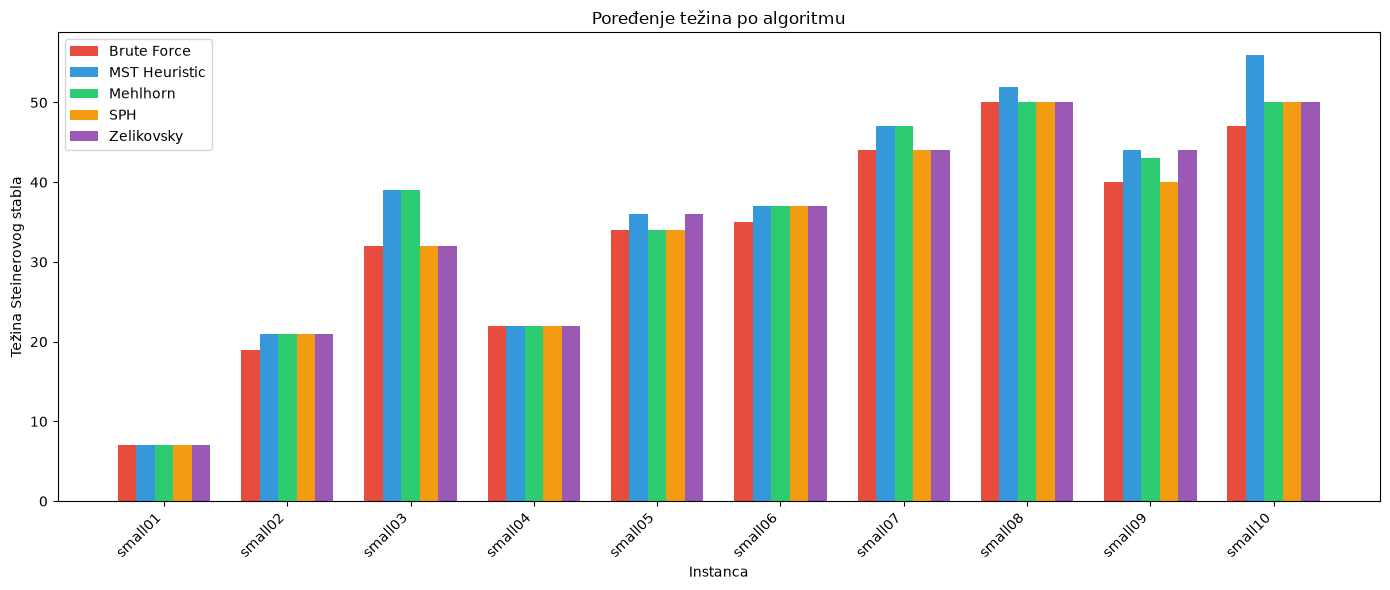

In [21]:
plot_weights(results, algorithms)

## Odstupanje od optimuma

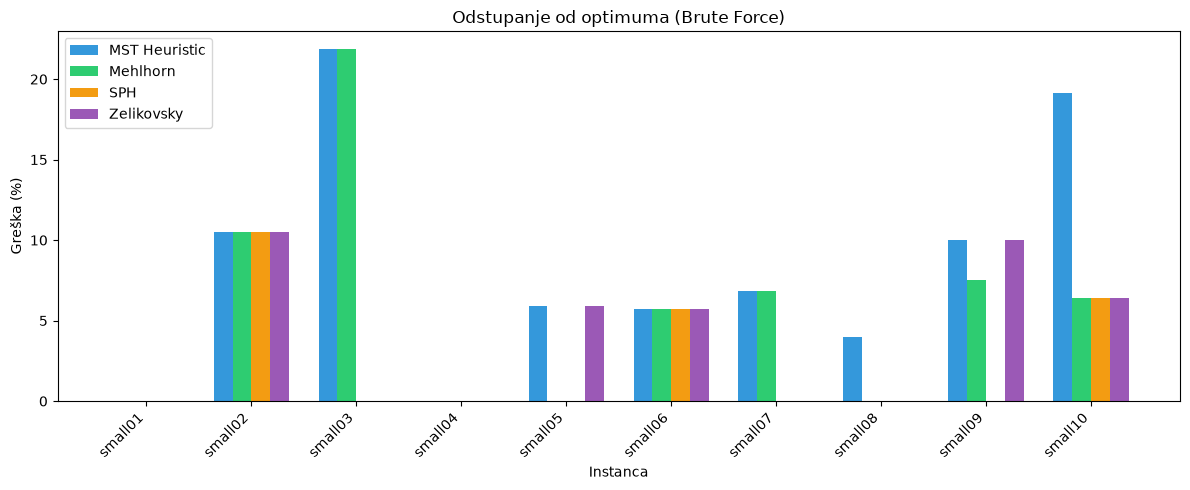

In [22]:
plot_errors(results, algorithms)

## Vreme izvršavanja

In [23]:
print_times(results, algorithms)

Instance      N    T |   Brute Fo    MST Heur    Mehlhorn         SPH    Zelikovs
---------------------------------------------------------------------------------
small01       5    3 |     0.0006s     0.0003s     0.0002s     0.0001s     0.0004s
small02      10    4 |     0.0035s     0.0002s     0.0002s     0.0003s     0.0017s
small03      15    5 |     0.0752s     0.0005s     0.0004s     0.0010s     0.0113s
small04      20    6 |     2.7435s     0.0006s     0.0004s     0.0017s     0.0150s
small05      25    7 |    46.1672s     0.0008s     0.0005s     0.0028s     0.0323s
small06      26    7 |   109.5439s     0.0008s     0.0005s     0.0027s     0.0378s
small07      27    7 |   173.8698s     0.0009s     0.0006s     0.0029s     0.0731s
small08      28    8 |   193.4990s     0.0011s     0.0006s     0.0049s     0.1185s
small09      29    8 |   424.0657s     0.0011s     0.0006s     0.0055s     0.0651s
small10      30    8 |   763.3767s     0.0013s     0.0006s     0.0048s     0.1328s


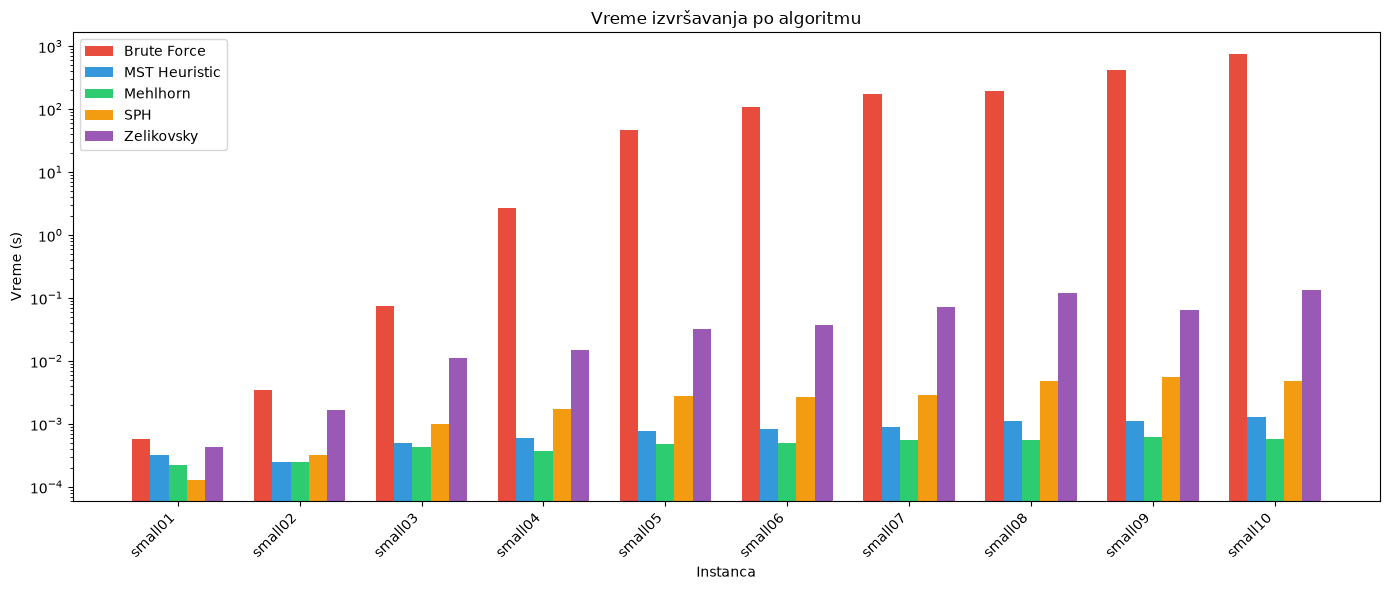

In [24]:
plot_times(results, algorithms)

## Prosečna greška po algoritmu

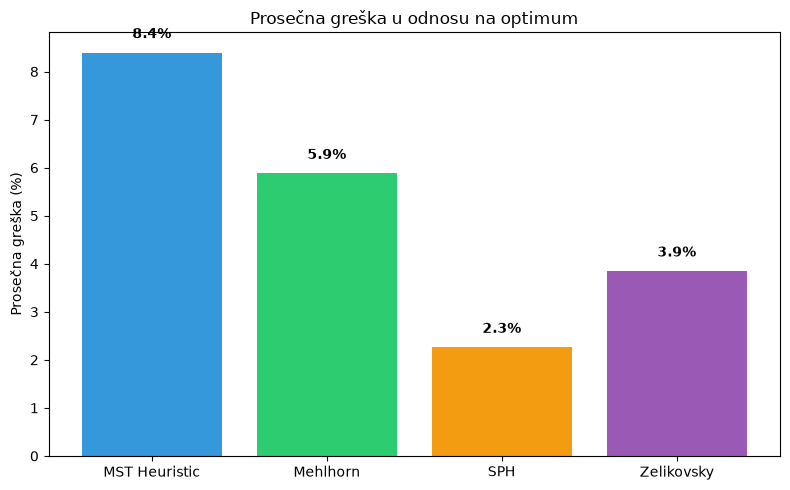

In [26]:
plot_avg_errors(results, algorithms)

## Brzina vs. kvalitet

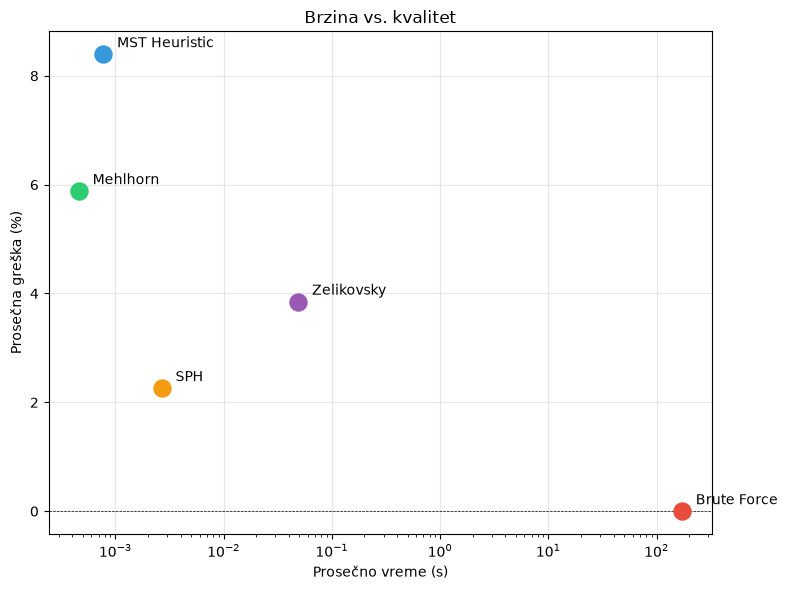

In [27]:
plot_speed_vs_quality(results, algorithms)

## Odnos težina (weight / optimum)

In [28]:
print_weight_ratios(results, algorithms)

Instance     OPT |   MST Heur    Mehlhorn         SPH    Zelikovs
-----------------------------------------------------------------
small01        7 |      1.0000      1.0000      1.0000      1.0000
small02       19 |      1.1053      1.1053      1.1053      1.1053
small03       32 |      1.2188      1.2188      1.0000      1.0000
small04       22 |      1.0000      1.0000      1.0000      1.0000
small05       34 |      1.0588      1.0000      1.0000      1.0588
small06       35 |      1.0571      1.0571      1.0571      1.0571
small07       44 |      1.0682      1.0682      1.0000      1.0000
small08       50 |      1.0400      1.0000      1.0000      1.0000
small09       40 |      1.1000      1.0750      1.0000      1.1000
small10       47 |      1.1915      1.0638      1.0638      1.0638

Prosečni odnosi:
  MST Heuristic: 1.0840
  Mehlhorn: 1.0588
  SPH: 1.0226
  Zelikovsky: 1.0385


## Zelikovsky varijante (SPH i Mehlhorn baza) — test na small10

In [33]:
algorithms_z = [
    ('Zelikovsky', zelikovsky_steiner, False),
    ('Zel+SPH', zelikovsky_sph, False),
    ('Zel+Mehlhorn', zelikovsky_mehlhorn, False),
]

results_z = compare_algorithms(algorithms_z, small_files)

Instance      N    T | Zeliko  Zel+SP  Zel+Me
---------------------------------------------
small01       5    3 |      7       *       *
small02      10    4 |     21       *       *
small03      15    5 |     32       *       *
small04      20    6 |     22       *       *
small05      25    7 |     36   34+-6%   34+-6%
small06      26    7 |     37       *       *
small07      27    7 |     44       *       *
small08      28    8 |     50       *       *
small09      29    8 |     44   40+-9%   43+-2%
small10      30    8 |     50       *       *

* = optimalno rešenje, - = preskočeno (preveliko za brute force)


## Poređenje svih 7 algoritama

In [34]:
results_all = []
for r, rz in zip(results, results_z):
    merged = dict(r)
    merged['Zel+SPH'] = rz['Zel+SPH']
    merged['Zel+SPH_time'] = rz['Zel+SPH_time']
    merged['Zel+Mehlhorn'] = rz['Zel+Mehlhorn']
    merged['Zel+Mehlhorn_time'] = rz['Zel+Mehlhorn_time']
    results_all.append(merged)

algorithms_all = [
    ('Brute Force', brute_force_steiner, True),
    ('MST Heuristic', mst_heuristic, False),
    ('Mehlhorn', mehlhorn_steiner, False),
    ('SPH', sph_steiner, False),
    ('Zelikovsky', zelikovsky_steiner, False),
    ('Zel+SPH', zelikovsky_sph, False),
    ('Zel+Mehlhorn', zelikovsky_mehlhorn, False),
]

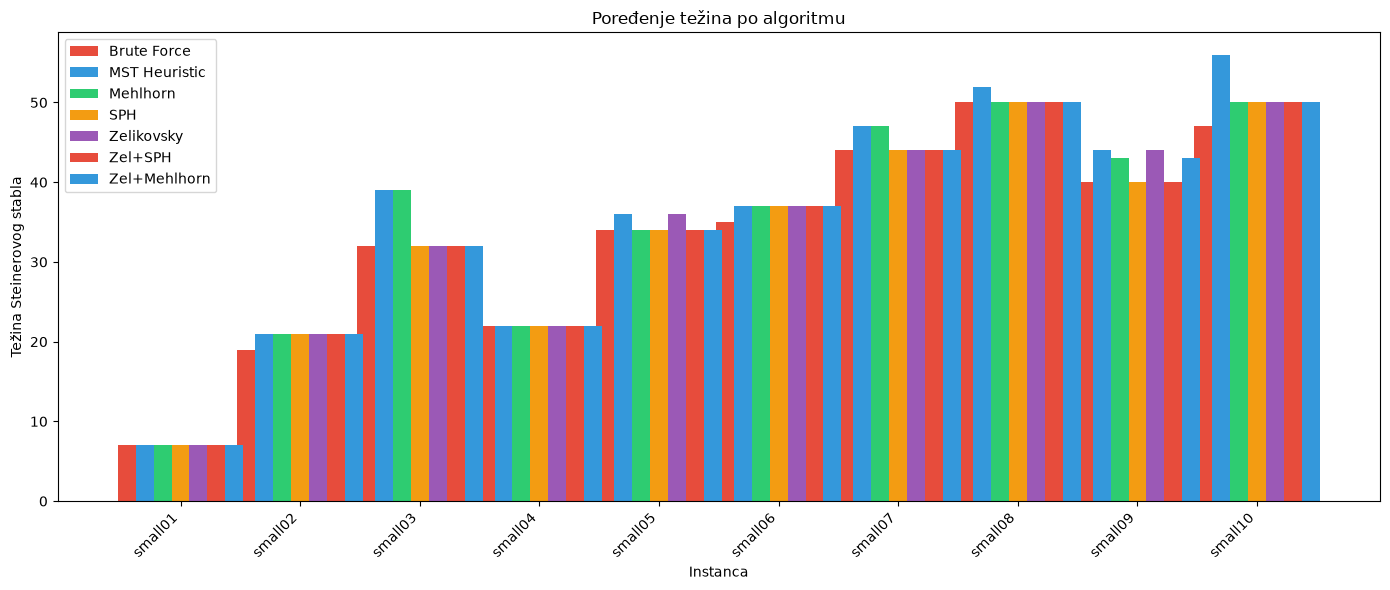

In [35]:
plot_weights(results_all, algorithms_all)

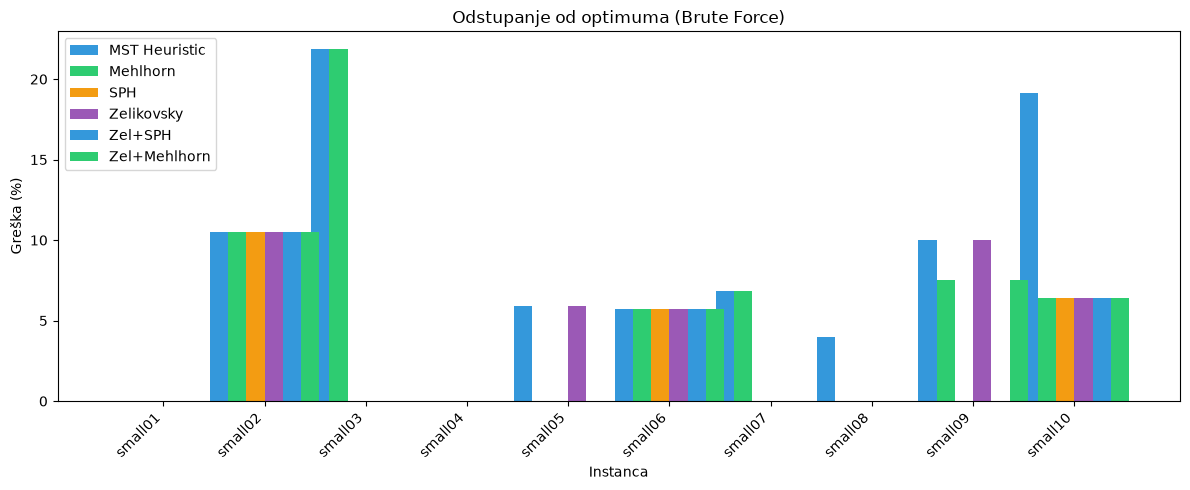

In [36]:
plot_errors(results_all, algorithms_all)

In [37]:
print_times(results_all, algorithms_all)

Instance      N    T |   Brute Fo    MST Heur    Mehlhorn         SPH    Zelikovs     Zel+SPH    Zel+Mehl
---------------------------------------------------------------------------------------------------------
small01       5    3 |     0.0006s     0.0003s     0.0002s     0.0001s     0.0004s     0.0004s     0.0005s
small02      10    4 |     0.0035s     0.0002s     0.0002s     0.0003s     0.0017s     0.0018s     0.0019s
small03      15    5 |     0.0752s     0.0005s     0.0004s     0.0010s     0.0113s     1.3551s     0.0118s
small04      20    6 |     2.7435s     0.0006s     0.0004s     0.0017s     0.0150s     0.0168s     0.0151s
small05      25    7 |    46.1672s     0.0008s     0.0005s     0.0028s     0.0323s     0.0353s     0.0331s
small06      26    7 |   109.5439s     0.0008s     0.0005s     0.0027s     0.0378s     0.0358s     0.0398s
small07      27    7 |   173.8698s     0.0009s     0.0006s     0.0029s     0.0731s     0.0413s     0.0752s
small08      28    8 |   193.4990s     

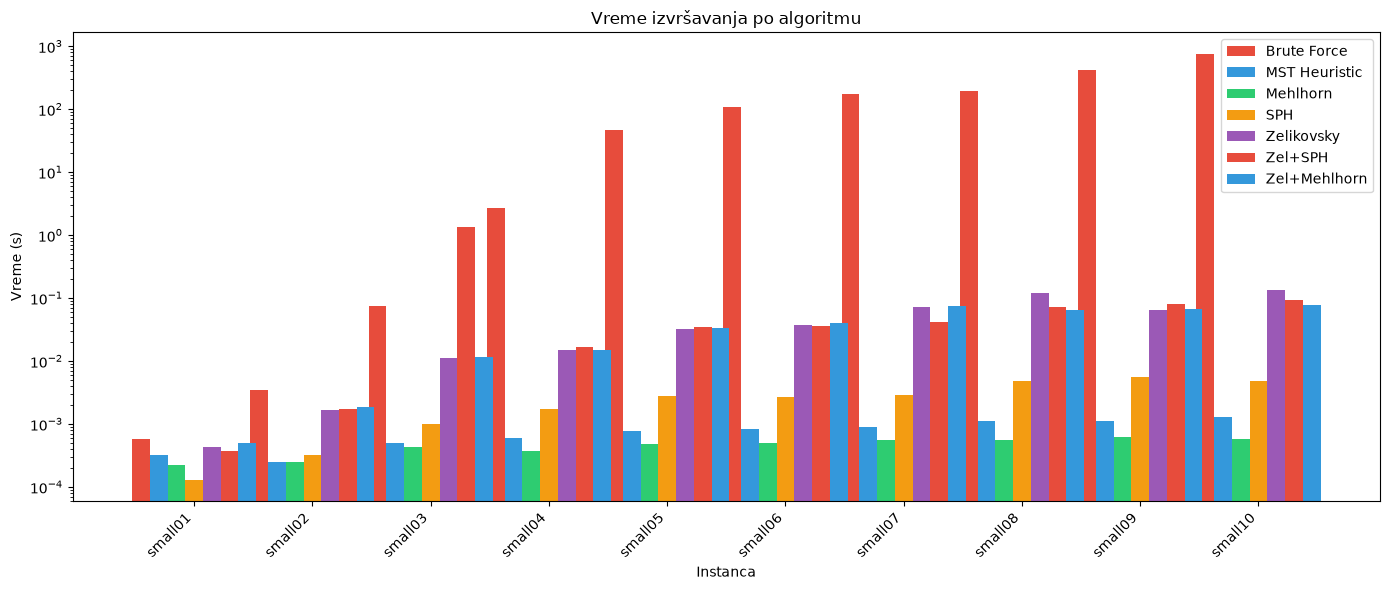

In [38]:
plot_times(results_all, algorithms_all)

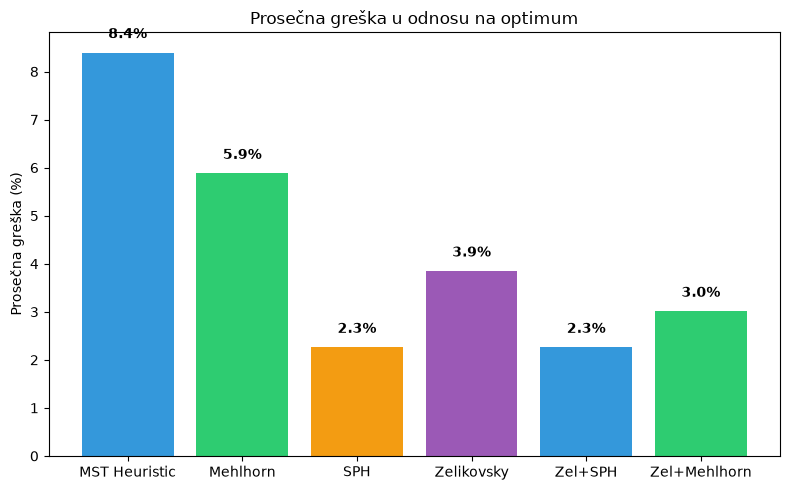

In [39]:
plot_avg_errors(results_all, algorithms_all)

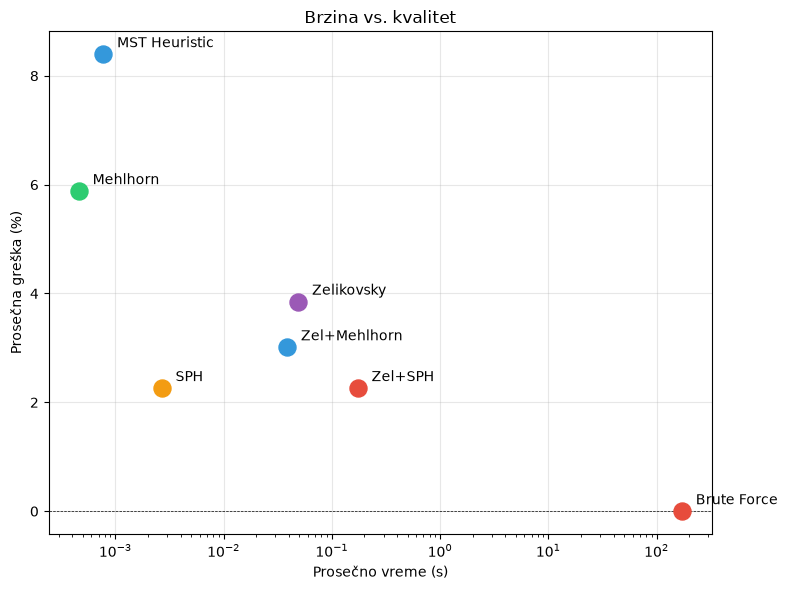

In [40]:
plot_speed_vs_quality(results_all, algorithms_all)

In [41]:
print_weight_ratios(results_all, algorithms_all)

Instance     OPT |   MST Heur    Mehlhorn         SPH    Zelikovs     Zel+SPH    Zel+Mehl
-----------------------------------------------------------------------------------------
small01        7 |      1.0000      1.0000      1.0000      1.0000      1.0000      1.0000
small02       19 |      1.1053      1.1053      1.1053      1.1053      1.1053      1.1053
small03       32 |      1.2188      1.2188      1.0000      1.0000      1.0000      1.0000
small04       22 |      1.0000      1.0000      1.0000      1.0000      1.0000      1.0000
small05       34 |      1.0588      1.0000      1.0000      1.0588      1.0000      1.0000
small06       35 |      1.0571      1.0571      1.0571      1.0571      1.0571      1.0571
small07       44 |      1.0682      1.0682      1.0000      1.0000      1.0000      1.0000
small08       50 |      1.0400      1.0000      1.0000      1.0000      1.0000      1.0000
small09       40 |      1.1000      1.0750      1.0000      1.1000      1.0000      1.0750
s